In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapster.constants import *
from astropy.cosmology import Planck18

# Data loading

In [2]:
location = 'Results_Test/'

# load evolution:
evolution = pd.DataFrame(np.loadtxt(location+'evolution.txt'), columns=evolution_keys);

# load mergers:
mergers = pd.DataFrame(np.loadtxt(location+'mergers.txt'), columns=merger_keys);

# load hardening:
hardening = pd.DataFrame(np.loadtxt(location+'hardening.txt'), columns=hardening_keys);

# load tdes:
tdes = pd.DataFrame(np.loadtxt(location+'tdes.txt'), columns=tdes_keys);

# load outputBHs:
outBHs = np.load(location+'outputBHs.pkl', allow_pickle=True)

# Cluster evolution

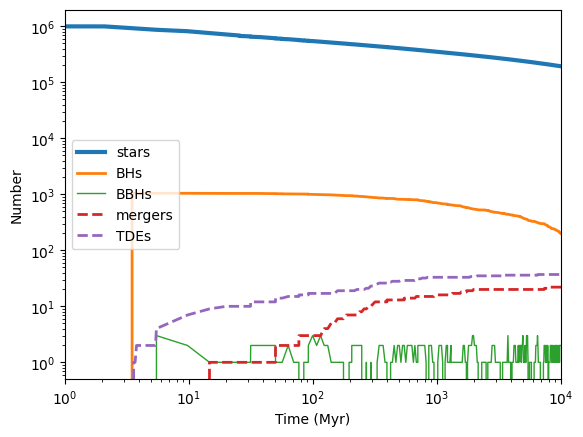

In [3]:
plt.plot(evolution['t'], evolution['M_cl']/evolution['m_avg'], lw=3, label=r'stars')
plt.plot(evolution['t'], evolution['N_BH'], lw=2, label=r'BHs')
plt.plot(evolution['t'], evolution['N_BBH'], lw=1, label=r'BBHs')
plt.plot(evolution['t'], evolution['N_me'], lw=2, ls='--', label=r'mergers')
plt.plot(evolution['t'], evolution['N_tdeBHWD']+evolution['N_tdeBHstar'], lw=2, ls='--', label=r'TDEs')

plt.legend()
plt.loglog()
plt.xlim(1, 1e4)
plt.xlabel(r'Time (Myr)')
plt.ylabel(r'Number')

plt.show()

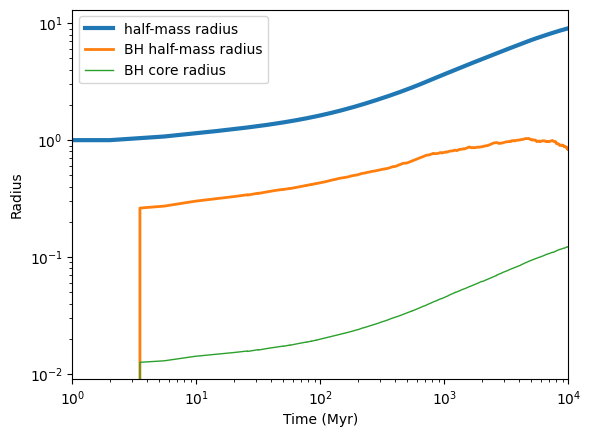

In [4]:
plt.plot(evolution['t'], evolution['r_h'], lw=3, label=r'half-mass radius')
plt.plot(evolution['t'], evolution['r_hBH'], lw=2, label=r'BH half-mass radius')
plt.plot(evolution['t'], evolution['r_cBH'], lw=1, label=r'BH core radius')

plt.legend()
plt.loglog()
plt.xlim(1, 1e4)
plt.xlabel(r'Time (Myr)')
plt.ylabel(r'Radius')

plt.show()

# BH mass function evolution

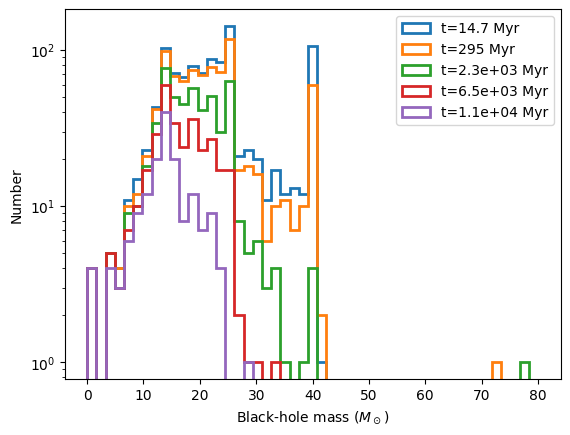

In [5]:
bins = np.linspace(0, 80)

plt.hist(outBHs['mBH'][57], histtype='step', bins=bins, lw=2, label=f"t={outBHs['t'][57]:.3g} Myr")
plt.hist(outBHs['mBH'][100], histtype='step', bins=bins, lw=2, label=f"t={outBHs['t'][100]:.3g} Myr")
plt.hist(outBHs['mBH'][200], histtype='step', bins=bins, lw=2, label=f"t={outBHs['t'][200]:.2g} Myr")
plt.hist(outBHs['mBH'][300], histtype='step', bins=bins, lw=2, label=f"t={outBHs['t'][300]:.2g} Myr")
plt.hist(outBHs['mBH'][400], histtype='step', bins=bins, lw=2, label=f"t={outBHs['t'][400]:.2g} Myr")

plt.legend()
plt.semilogy()
plt.xlabel(r'Black-hole mass $(M_\odot)$')
plt.ylabel(r'Number')

plt.show()

# BBH mergers

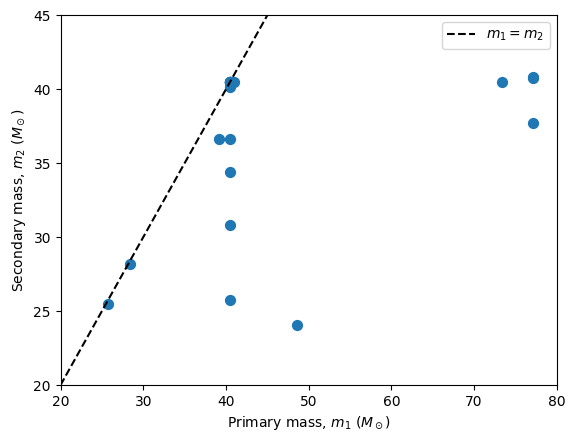

In [6]:
plt.scatter(mergers['m1'], mergers['m2'], s=50, marker='o')

x=np.linspace(0, 50)
plt.plot(x, x, color='k', ls='--', label=r'$m_1=m_2$')
plt.legend()
plt.xlim(20, 80)
plt.ylim(20, 45)
plt.xlabel(r'Primary mass, $m_1$ ($M_\odot$)')
plt.ylabel(r'Secondary mass, $m_2$ ($M_\odot$)')
plt.show()

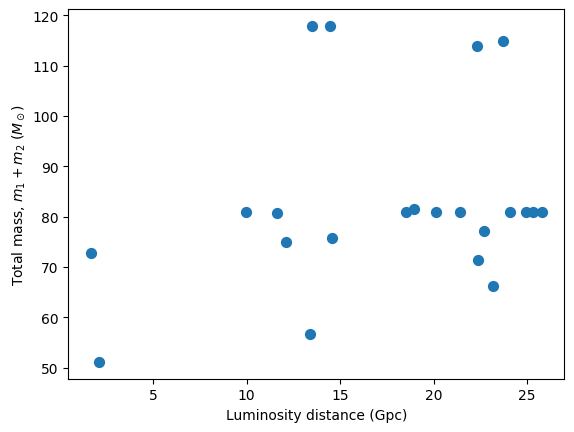

In [7]:
plt.scatter(Planck18.luminosity_distance(mergers['z'])/1e3, mergers['m1']+mergers['m2'], s=50, marker='o')

plt.xlabel(r'Luminosity distance (Gpc)')
plt.ylabel(r'Total mass, $m_1+m_2$ ($M_\odot$)')
plt.show()

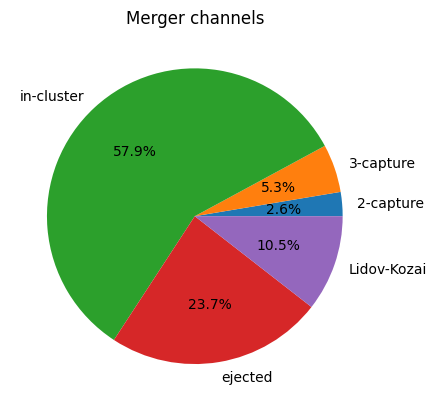

In [8]:
cap2 = (mergers['channel']==2)
cap3 = (mergers['channel']==6)
eject = mergers['channel']<0
zlk = mergers['channel']==4

sizes = [
    mergers['channel'][cap2].size, 
    mergers['channel'][cap3].size, 
    mergers['channel'][~(cap2*cap3*eject*zlk)].size, 
    mergers['channel'][eject].size, 
    mergers['channel'][zlk].size
]
labels = ['2-capture', '3-capture', 'in-cluster', 'ejected', 'Lidov-Kozai']

plt.title('Merger channels')
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.show()

# Tidal disruption events:

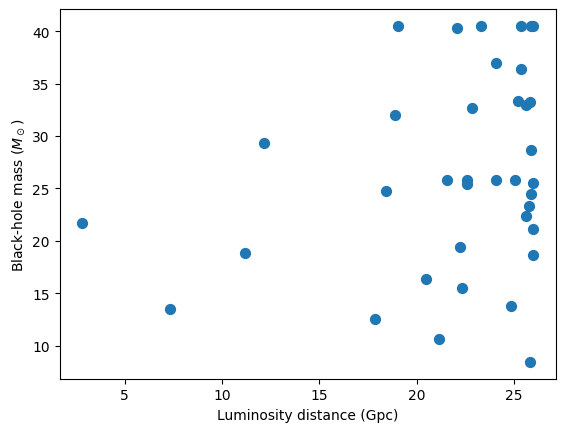

In [9]:
plt.scatter(Planck18.luminosity_distance(tdes['z'])/1e3, tdes['m_BH'], s=50, marker='o')

plt.xlabel(r'Luminosity distance (Gpc)')
plt.ylabel(r'Black-hole mass ($M_\odot$)')
plt.show()

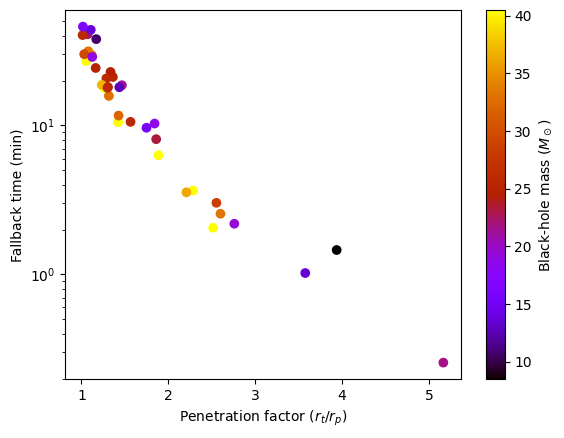

In [10]:
Myr = 1e6*365*24*60*60
plt.scatter(tdes['beta'], tdes['t_fb']*Myr/60, c=tdes['m_BH'], cmap='gnuplot')
plt.colorbar(label=r'Black-hole mass ($M_\odot$)')
plt.semilogy()

plt.xlabel(r'Penetration factor ($r_t/r_p$)')
plt.ylabel(r'Fallback time (min)')
plt.show()

# Hardening of binaries

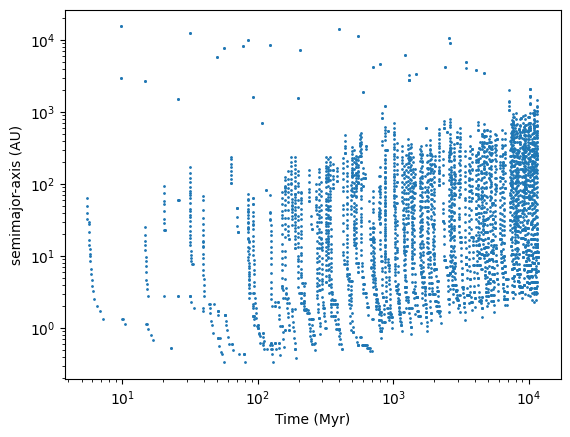

In [11]:
plt.scatter(hardening['t']+hardening['t_local']+hardening['dt_local'], hardening['a']*3.086e+16/1.496e+11, s=1)
plt.loglog()

plt.loglog()
plt.xlabel('Time (Myr)')
plt.ylabel('semimajor-axis (AU)')
plt.show()

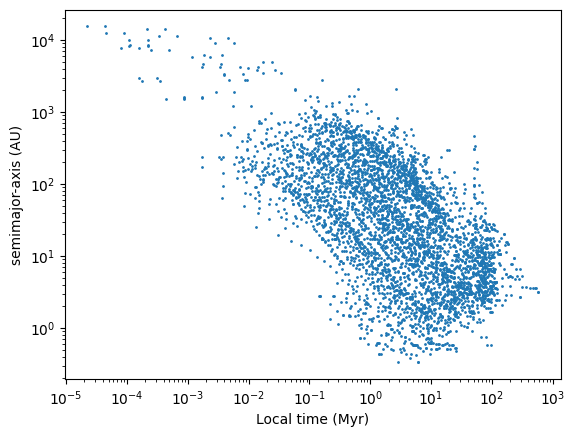

In [12]:
plt.scatter(hardening['t_local']+hardening['dt_local'], hardening['a']*3.086e+16/1.496e+11, s=1)

plt.loglog()
plt.xlabel('Local time (Myr)')
plt.ylabel('semimajor-axis (AU)')
plt.show()